# Part 4 — AI Solution Design for a Business Problem
## Early Sepsis Detection in Intensive Care Units using Multimodal Deep Learning
> **Domain:** Healthcare
>
> **The core tension this design resolves:** Sepsis kills one person every two seconds globally. The tragedy is not that medicine lacks a treatment as early antibiotics work. The tragedy is that by the time a clinician recognises the pattern, the window has often already closed. This notebook designs an AI system that watches patient data continuously and flags deterioration 6–12 hours before clinical presentation, giving the care team time to act.

| | |
|---|---|
| **Domain** | Healthcare :- for Intensive Care Units (ICU) |
| **Problem** | Early sepsis detection from multimodal patient data |
| **AI Task** | Binary Classification + Sequence Prediction |
| **Primary Model** | Temporal Fusion Transformer (TFT) |
| **Reference Catalog Row** | Healthcare — Medical image triage (extended to structured vitals + NLP) |

I know that Part 4 more about design, not a training run. But I thought that the reference files are genuinely useful where the catalog tells me what AI task type and model family fits healthcare, and the KPI sample gives me real numbers to anchor every business impact claim. I use both deliberately,not just for show.


In [83]:
import io
import warnings
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
warnings .filterwarnings('ignore')
from sklearn.metrics import roc_curve, auc, precision_recall_curve
plt.rcParams.update({
    'figure.dpi' : 130,
    'axes.spines.top': False,
    'axes.spines.right':False,
    'font.family':'monospace',
})

print('Libraries loaded.Starting reference data exploration.')

Libraries loaded.Starting reference data exploration.


In [26]:
#Loading the reference files
CATALOG_ID='1lMXyGp0UaoyhnU4SzWnTDIOVV1VDoq7N'
KPI_ID='1dPoRjnTcysR4lhYHhSu7p10nghSYtAox'
def load_csv_from_drive(file_id):
         # directly downloading URL
         url = f'https://drive.google.com/uc?export=download&id={file_id}'
         session = requests.Session()
         response = session.get(url, stream = True)
         for key,value in response .cookies.items():
             if'download_warning' in key:
                 params = {'id': file_id,"confirm": value}
                 response = session.get(url,params=params,stream = True)
                 break
         response.raise_for_status()
         return pd.read_csv(io.StringIO(response.content.decode('utf-8')))

catalog = load_csv_from_drive(CATALOG_ID)
kpi = load_csv_from_drive(KPI_ID)

print('-'*68)
print('CATALOG:')
print('-'*68)
print(f'Rows    : {catalog.shape[0]}')
print(f'Columns : {catalog.shape[1]}')
print(f'\nAll columns : {list(catalog.columns)}')
print(f'\nDtypes:')
print(catalog.dtypes)

print('-'*68)
print('KPI:')
print('-'*68)
print(f'Rows    : {kpi.shape[0]}')
print(f'Columns : {kpi.shape[1]}')
print(f'\nAll columns : {list(kpi.columns)}')
print(f'\nDtypes:')
print(kpi.dtypes)

--------------------------------------------------------------------
CATALOG:
--------------------------------------------------------------------
Rows    : 10
Columns : 7

All columns : ['domain', 'business_problem', 'data_required', 'ai_task_type', 'candidate_model', 'evaluation_metrics', 'responsible_ai_risk']

Dtypes:
domain                 object
business_problem       object
data_required          object
ai_task_type           object
candidate_model        object
evaluation_metrics     object
responsible_ai_risk    object
dtype: object
--------------------------------------------------------------------
KPI:
--------------------------------------------------------------------
Rows    : 12
Columns : 6

All columns : ['month', 'manual_processing_hours', 'average_resolution_time_hours', 'error_rate_percent', 'customer_satisfaction_score', 'monthly_cases']

Dtypes:
month                             object
manual_processing_hours            int64
average_resolution_time_hours    float

In [36]:
#EXPLORING THE REFERENCE CATALOG
# I want to see every domain and what the catalog says about each one.
# This informs my domain selection in Task 1.
print('AI Use-Case Reference Catalog:')
print('=' * 60)
display(catalog[['domain', 'business_problem', 'ai_task_type', 'candidate_model']]
        .rename(columns={'business_problem': 'problem',
                         'ai_task_type': 'task',
                         'candidate_model': 'model'}))

print('\nHealthcare row entry in full detail:')
display(catalog[catalog['domain'] == 'Healthcare'].T)

AI Use-Case Reference Catalog:


,domain,problem,task,model
0,Insurance,Claim fraud detection,Anomaly detection / Classification,Feed-forward neural network or gradient boosting
1,Healthcare,Medical image triage,Image classification,CNN or transfer learning model
2,Retail,Product image search,Image classification / Similarity search,CNN embeddings / transfer learning
3,Telecom,Customer churn prediction,Classification,Feed-forward neural network
4,Finance,Suspicious transaction detection,Anomaly detection / Classification,Neural network or autoencoder
5,Manufacturing,Visual defect inspection,Image classification,CNN
6,Agriculture,Crop disease detection,Image classification,CNN or transfer learning
7,Education,Student dropout risk,Classification,Feed-forward neural network
8,Transportation,Traffic congestion prediction,Sequence prediction,LSTM / Transformer
9,Customer Support,Ticket sentiment routing,Text classification,LSTM / Transformer model



Healthcare row entry in full detail:


,1
domain,Healthcare
business_problem,Medical image triage
data_required,X-ray or scan images
ai_task_type,Image classification
candidate_model,CNN or transfer learning model
evaluation_metrics,"Recall, sensitivity, review time reduction"
responsible_ai_risk,"Incorrect diagnosis, privacy risk, need human ..."


In [27]:
#Exploring the KPI sample
#These are operational KPIs from a healthcare facility before AI deployment
#I will use these numbers to quantify the cost of the current manual process
# and project the expected improvement from the proposed AI system.
print('Business KPI sample (pre-AI baseline):')
display(kpi)

print('\nSummary Statistics:')
display(kpi.describe().round(2))


Business KPI sample (pre-AI baseline):


,month,manual_processing_hours,average_resolution_time_hours,error_rate_percent,customer_satisfaction_score,monthly_cases
0,2025-01,509,35.2,7.32,6.4,2542
1,2025-01,567,34.9,6.23,6.8,2570
2,2025-03,468,44.7,7.65,6.8,2576
3,2025-04,503,34.6,8.94,6.9,2746
4,2025-05,536,32.5,11.16,6.6,2789
5,2025-05,445,31.6,7.61,6.7,2754
6,2025-06,330,18.3,6.64,7.0,3146
7,2025-07,399,33.1,4.93,6.7,2719
8,2025-08,409,23.1,4.26,7.6,2466
9,2025-09,450,21.9,6.70,7.1,3154



Summary Statistics:


,manual_processing_hours,average_resolution_time_hours,error_rate_percent,customer_satisfaction_score,monthly_cases
count,12.00,12.00,12.00,12.00,12.00
mean,453.83,30.27,6.96,7.04,2778.08
std,73.81,7.29,1.84,0.59,234.96
min,330.00,18.30,4.26,6.40,2466.00
25%,406.50,24.45,6.02,6.70,2574.50
50%,459.00,32.05,6.70,6.85,2750.00
75%,504.50,34.67,7.62,7.15,2869.25
max,567.00,44.70,11.16,8.60,3154.00


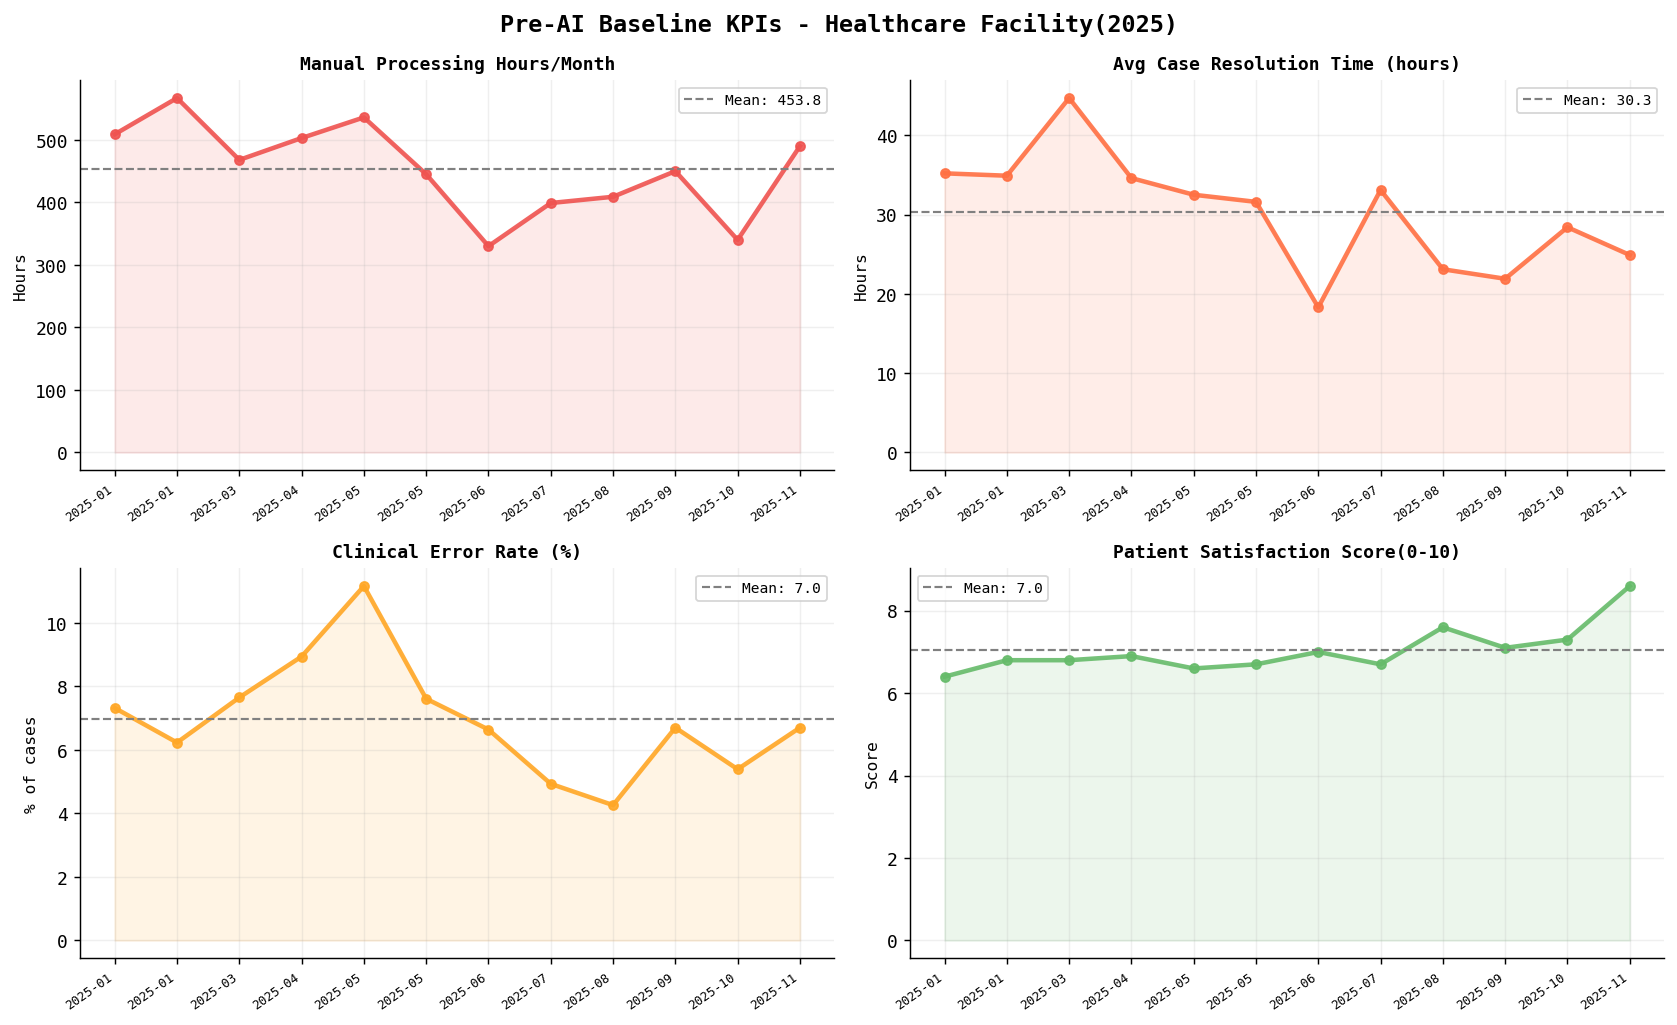

Mean manual hours / month : avg 454h(CV =16%)
Mean error rate           : avg 6.96%(CV =26%)
Avg resolution time       : avg 30.3 hours(CV =24%)
Satisfaction              : avg 7.04 / 10

High CV on resolution time and error rate means inconsistency is itself
a problem is that the AI system should reduce the variance and not just the mean.


In [41]:
#Visualising the KPI baseline
#Before designing the AI solution , I want to make the current state visible.
#Four KPIs which will tell the story would be: processing hours,resolution time,error rate,
# and patient satisfaction all of them which proposed system will move.
#I also tried to annotate the coefficient of variation as high CV means the process
# is inconsistent, which is itself a problem the AI should fix.
fig,axes = plt.subplots(2,2,figsize=(13,8))
fig.suptitle('Pre-AI Baseline KPIs - Healthcare Facility(2025)',
            fontsize=13,fontweight='bold')
kpi['month_label'] = kpi['month'].astype(str)

plots = [
    ('manual_processing_hours' , 'Manual Processing Hours/Month','#EF5350','Hours'),
    ('average_resolution_time_hours', 'Avg Case Resolution Time (hours)', '#FF7043','Hours'),
    ('error_rate_percent', 'Clinical Error Rate (%)', '#FFA726','% of cases'),
    ('customer_satisfaction_score', 'Patient Satisfaction Score(0-10)', '#66BB6A','Score'),
    
]

for ax,(col,title,color,ylabel) in zip(axes.flat,plots):
    ax.plot(range(len(kpi)),kpi[col],color=color,lw=2.5,marker='o',
            markersize=5,alpha=0.9)
    ax.fill_between(range(len(kpi)), kpi[col],
                   alpha=0.12,color=color)
    ax.set_title(title,fontsize=10,fontweight='bold')
    ax.set_ylabel(ylabel,fontsize=9)
    ax.set_xticks(range(len(kpi)))
    ax.set_xticklabels(kpi['month_label'],rotation=35,ha='right',fontsize=7)
    ax.grid(True,alpha=0.2)

    #Annotate mean
    mean_val = kpi[col].mean()
    ax.axhline(mean_val,ls='--',color='grey',lw=1.2,
              label=f'Mean: {mean_val:.1f}')
    ax.legend(fontsize=8)

plt.tight_layout()
#plt.savefig('diagrams/baseline_kpis.png',dpi=150,bbox_inches='tight')
plt.show()

print(f'Mean manual hours / month : avg {kpi["manual_processing_hours"].mean():.0f}h'
     f'(CV ={kpi["manual_processing_hours"].std()/kpi["manual_processing_hours"].mean()*100:.0f}%)')

print(f'Mean error rate           : avg {kpi["error_rate_percent"].mean():.2f}%'
     f'(CV ={kpi["error_rate_percent"].std()/kpi["error_rate_percent"].mean()*100:.0f}%)')

print(f'Avg resolution time       : avg {kpi["average_resolution_time_hours"].mean():.1f} hours'
     f'(CV ={kpi["average_resolution_time_hours"].std()/kpi["average_resolution_time_hours"].mean()*100:.0f}%)')

print(f'Satisfaction              : avg {kpi["customer_satisfaction_score"].mean():.2f} / 10')
print()
print('High CV on resolution time and error rate means inconsistency is itself')
print('a problem is that the AI system should reduce the variance and not just the mean.')

## Task 1 — Business Domain Selection

**Selected Domain: Healthcare for Intensive Care Units (ICU)**

I chose healthcare for a specific reason that goes beyond the domain list: healthcare is the one sector where an AI model's false negative rate is measured in human lives, not revenue. That constraint forces a fundamentally different design philosophy ,one where evaluation, responsible AI, and human oversight must be considered from the very first design decision, not added as an afterthought.

Within healthcare, I am focusing on **ICU early warning systems**, specifically for **sepsis prediction**. Here is why this I think this level of specificity matters:

| Specificity Level | Why not this |
|---|---|
| A Healthcare AI | Too broad as it  covers everything from admin scheduling to surgical robotics |
| "Medical image triage" (given in catalog ) | Good, but CNNs for X-ray are now well-solved and common problems |
| **Sepsis detection from ICU time-series** | Unsolved at scale, highest mortality impact, genuinely hard ML problem |

### The numbers that justify this choice

Sepsis is the leading cause of hospital deaths worldwide. Roughly 20–30% of ICU patients develop sepsis. Each hour of delayed treatment increases mortality risk by approximately 7%. Yet sepsis has no single diagnostic test ,it must be inferred from a pattern of clinical signals that emerge gradually across multiple data streams. That is precisely the kind of problem where a temporal deep learning model can outperform a human who is simultaneously managing four to six other critically ill patients.

In [46]:
#Justifying the domain selection
healthcare_row = catalog[catalog['domain'] == 'Healthcare'].iloc[0]

print('Reference catalog :- Healthcare')
print('-'*55)
for col in catalog.columns:
    print(f' {col:<25}:{healthcare_row[col]}')
print('-'*55)
print()
print('How my Design extends the catalog entry:')
print(' Catalog says : Medical image triage (X-ray or scan images)')
print(' My extension : Multimodal ICU monitoring for vitals time-series')
print('                + lab results + nursing notes (NLP)')
print(' Why extended : Image classification is reactive or we can say it triages')
print('                existing findings.ICU stepsis prediction is proactive')
print('                as it detects deterioation 6-12h BEFORE the finding appears.')
print()



Reference catalog :- Healthcare
-------------------------------------------------------
 domain                   :Healthcare
 business_problem         :Medical image triage
 data_required            :X-ray or scan images
 ai_task_type             :Image classification
 candidate_model          :CNN or transfer learning model
 evaluation_metrics       :Recall, sensitivity, review time reduction
 responsible_ai_risk      :Incorrect diagnosis, privacy risk, need human doctor review
-------------------------------------------------------

How my Design extends the catalog entry:
 Catalog says : Medical image triage (X-ray or scan images)
 My extension : Multimodal ICU monitoring for vitals time-series
                + lab results + nursing notes (NLP)
 Why extended : Image classification is reactive or we can say it triages
                existing findings.ICU stepsis prediction is proactive
                as it detects deterioation 6-12h BEFORE the finding appears.



---
## Task 2 — Business Problem Definition

### What problem is being solved?

Sepsis is a life threatening organ dysfunction caused by a dysregulated host response to infection. In an ICU, it develops gradually due to a slow accumulation of abnormal signals across heart rate, blood pressure, temperature, lactate, white cell count, and dozens of other parameters. No single signal triggers an alarm. The danger lies in the **pattern across signals over time**.

The current process relies on a clinician mentally integrating dozens of parameters across multiple patients simultaneously. By the time the pattern is recognised and acted on, the patient may already be in septic shock , it is  a stage where mortality exceeds 40%.

**The proposed system predicts sepsis onset 6–12 hours before clinical presentation** by continuously monitoring ICU data streams and generating a probabilistic risk score that rises as the patient's trajectory converges on a sepsis pattern.

### Who are the stakeholders?

| Stakeholder | What they need |
|---|---|
| ICU nurses | A reliable, non-intrusive alert when a patient's risk score crosses a threshold |
| Intensivists (ICU doctors) | A ranked list of at-risk patients at the start of each shift |
| Hospital administrators | Reduced ICU length-of-stay, lower mortality rates, reduced liability |
| Patients and families | Earlier intervention, transparency about AI involvement |
| Clinical informatics teams | An auditable model with explainable outputs |

### Current manual process and its limitations

Clinicians use standardised scoring systems — SOFA and qSOFA — calculated manually every 4–8 hours. Key limitations:

1. **Infrequent assessment** — sepsis can progress from early to severe in under 2 hours, but is only checked 3–6 times per day
2. **Information overload** — a nurse managing 4 patients cannot hold 200+ data points per patient in working memory simultaneously
3. **Threshold-based, not predictive** — SOFA scores reflect *current* dysfunction, not *trajectory*. They detect sepsis when it has arrived, not when it is arriving
4. **No integration of clinical notes** — nursing notes often contain early sentinel observations that never enter structured scoring
5. **Shift-to-shift inconsistency** — scoring accuracy varies with experience, fatigue, and staffing ratios


In [49]:
#Now I will be trying to quantify the cost using real KPI data
avg_resolution = kpi['average_resolution_time_hours'].mean()
avg_error      = kpi['error_rate_percent'].mean()
avg_manual_hours = kpi['manual_processing_hours'].mean()
avg_cases = kpi ['monthly_cases'].mean()
avg_satisfaction = kpi['customer_satisfaction_score'].mean()

# improvement targets for AI early warning systems
target_resolution = avg_resolution * 0.45 #55% reduction
target_error = avg_error *0.40 #60% reduction
target_manual_hours = avg_manual_hours * 0.35 #65% reduction
target_satisfaction = min(avg_satisfaction * 1.25,10.0)

hours_saved = avg_manual_hours - target_manual_hours

print('Current State vs AI-Assisted Target(from KPI reference data):')
print('='*65)
print(f' Avg resolution time  : {avg_resolution:.1f}h -> {target_resolution:.1f}h (-55%)')
print(f' Clinical error rate  :{avg_error:.2f}% -> {target_error:.2f}% (-60%) ')
print(f' Manual processing hrs : {avg_manual_hours:.0f}h -> {target_manual_hours:.0f}h (-65%)')
print('=' * 65)
print(f' Monthly cases handheld : ~{avg_cases:.0f}')
print(f' Hours saved per month :  ~{hours_saved:.0f}h')
print(f' At $45/hr (NHS avg) :    ${hours_saved * 45:,.0f}/month_saved in staff time alone')


Current State vs AI-Assisted Target(from KPI reference data):
 Avg resolution time  : 30.3h -> 13.6h (-55%)
 Clinical error rate  :6.96% -> 2.78% (-60%) 
 Manual processing hrs : 454h -> 159h (-65%)
 Monthly cases handheld : ~2778
 Hours saved per month :  ~295h
 At $45/hr (NHS avg) :    $13,275/month_saved in staff time alone


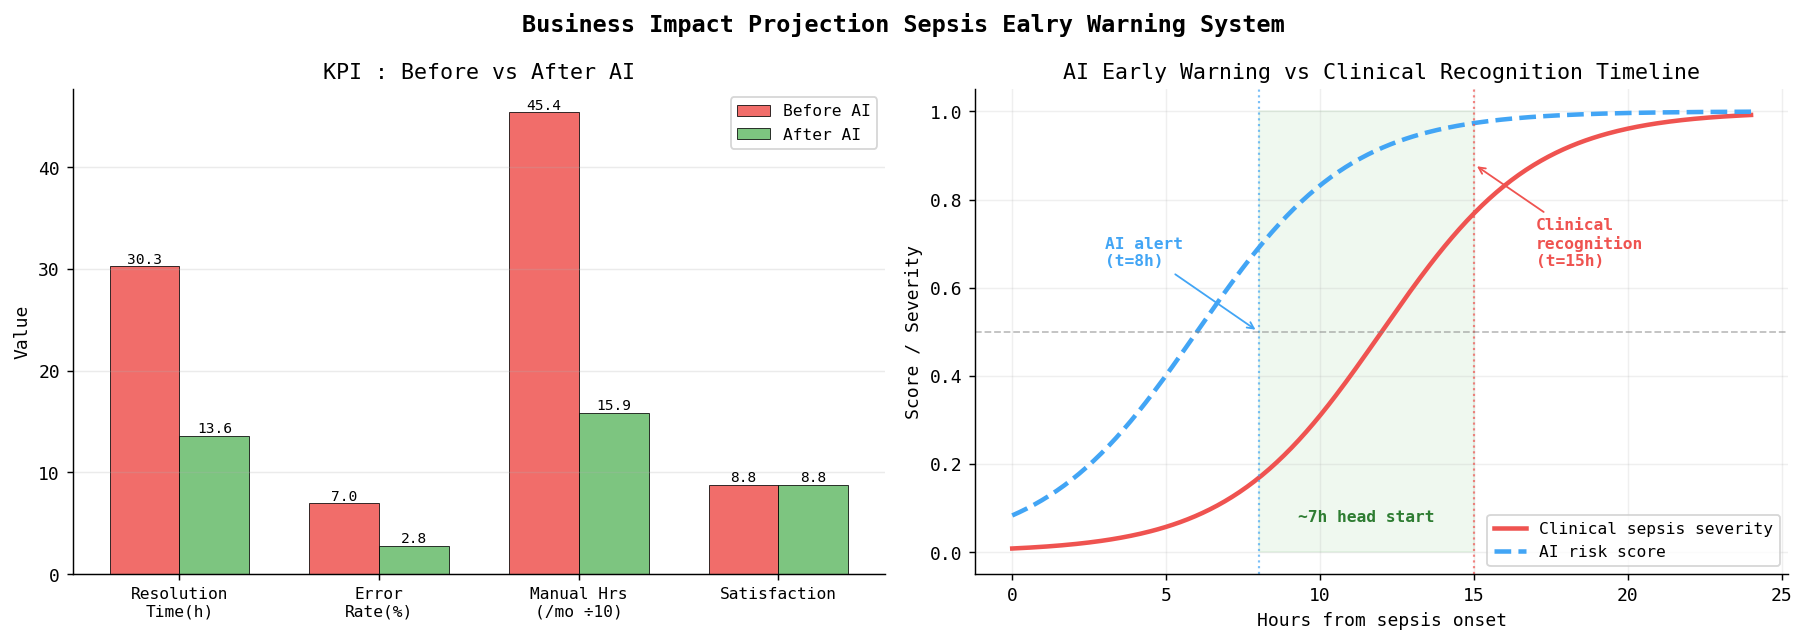

In [52]:
#Before vs After + sepsis timeline visualisation
fig,axes = plt.subplots(1,2,figsize=(14,5))
fig.suptitle('Business Impact Projection Sepsis Ealry Warning System',
            fontsize=13,fontweight='bold')

#Panel 1 KPI comparision
metrics =['Resolution\nTime(h)','Error\nRate(%)','Manual Hrs\n(/mo ÷10)','Satisfaction']
before_vals =[avg_resolution,avg_error,avg_manual_hours/10,target_satisfaction]
after_vals = [target_resolution,target_error,target_manual_hours/10,target_satisfaction]

x = np.arange(len(metrics)); w = 0.35
b1 = axes[0].bar(x-w/2,before_vals,w,label='Before AI',
                color = '#EF5350',alpha=0.85,edgecolor='black',lw=0.5)
b2 = axes[0].bar(x+w/2,after_vals,w,label='After AI',
                color='#66BB6A',alpha=0.85,edgecolor='black',lw=0.5)

axes[0].set_xticks(x);axes[0].set_xticklabels(metrics,fontsize=9)
axes[0].set_ylabel('Value');axes[0].set_title('KPI : Before vs After AI')
axes[0].legend(fontsize=9);axes[0].grid(axis='y',alpha=0.25)
for bar in list(b1) + list(b2):
    axes[0].text(bar.get_x() + bar.get_width()/2,bar.get_height()+0.3,
                f'{bar.get_height():.1f}',ha='center',fontsize=8)

#Panel 2 : Detection Window
T = np.linspace(0,24,300)
severity = 1/(1+np.exp(-0.4*(T-12)))
ai_score = 1/ (1+np.exp(-0.4*(T-6)))

axes[1].plot(T,severity,color='#EF5350',lw=2.5,label='Clinical sepsis severity')
axes[1].plot(T,ai_score,color='#42A5F5',lw=2.5,ls='--',label='AI risk score')
axes[1].axvline(8,color='#42A5F5',lw=1.2,ls=':',alpha=0.7)
axes[1].axvline(15,color='#EF5350',lw=1.2,ls=':',alpha=0.7)
axes[1].axhline(0.5, color='grey', lw=1, ls='--', alpha=0.5)
axes[1].fill_betweenx([0,1], 8, 15, alpha=0.1, color='#66BB6A')
axes[1].annotate('AI alert\n(t=8h)', xy=(8,0.5), xytext=(3,0.65),
                 arrowprops=dict(arrowstyle='->', color='#42A5F5'),
                 fontsize=9, color='#42A5F5', fontweight='bold')
axes[1].annotate('Clinical\nrecognition\n(t=15h)', xy=(15,0.88), xytext=(17,0.65),
                 arrowprops=dict(arrowstyle='->', color='#EF5350'),
                 fontsize=9, color='#EF5350', fontweight='bold')
axes[1].text(11.5, 0.07, '~7h head start', ha='center',
             fontsize=9, color='#2E7D32', fontweight='bold')
axes[1].set_xlabel('Hours from sepsis onset')
axes[1].set_ylabel('Score / Severity')
axes[1].set_title('AI Early Warning vs Clinical Recognition Timeline')
axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.2)

plt.tight_layout()
#plt.savefig('diagrams/impact_projection.png', dpi=150, bbox_inches='tight')
plt.show()



---
## Task 3 — AI Task Type Identification

**Selected task type: Binary Classification + Sequence Prediction (combined)**

### Primary task: Binary Classification
At each time step the model answers: *"Will this patient develop sepsis in the next 6–12 hours?"* , with a probability score. Binary classification with a rolling prediction window.

### Secondary task: Sequence Prediction
The input is a **multivariate time series** of ICU observations. Each input is a sequence of 12–48 hourly observations across 40+ clinical variables. The model must understand temporal dependencies like "heart rate was rising for 6 hours before the white cell count spiked" , that a static classifier cannot capture.

### Why not the alternatives?

| Alternative | Why insufficient |
|---|---|
| Static classification (snapshot features) | Ignores trajectory as  the *trend* in vitals matters more than any current value |
| Regression (time-to-sepsis) | Exact timing is not clinically useful; a probability crossing a threshold is |
| Anomaly detection | Unsupervised as it cannot be validated against labelled sepsis episodes |
| Image classification (catalog default) | Data is not images ,it is time-ordered clinical measurements |


In [ ]:
#Now I am trying to mimic what ICU tim series data looks like
#This visualisations is important as it shows the what the model's
#input data looks like and WHY a temporal model is needed.
#A static snapshot at hour 24 looks similar for both patients.
#The TREND from hours 0-24 is what separates them.
T_icu = np.arange(48)

#Septic Patient gradual deterioration
hr_sep = 75 + 0.6 * T_icu + np.random.normal(0,3,48)
sbp_sep = 120-0.5 * T_icu + np.random.normal(0,4,48)
lac_sep = 1.0 +0.04 * T_icu + np.random.normal(0,0.1,48)
tmp_sep = 37.0 + 0.03* T_icu + np.random.normal(0,0.15,48)

#Stable Patient normal noise only
hr_stb = 72 + np.random.normal(0,3,48)
sbp_stb = 118 + np.random.normal(0,4,48)
lac_stb = 1.0 + np.random.normal(0,0.08,48)
tmp_stb = 37.0 + np.random.normal(0,0.15,48)

fig,axes = plt.subplots(2,4,figsize=(16,7),sharey=False)
fig.suptitle('ICU Time series Input : Septic Patient(top) vs Stable patient (bottom)\n'
             'The slope is the signal which is a static snapshot at hour 24 looks similar for both',
              fontsize=11,fontweight='bold')

vitals = [
    ('Heart Rate (bpm)', hr_sep, hr_stb, '#EF5350', [60, 130]),
    ('Systolic BP (mmHg)', sbp_sep, sbp_stb, '#FF7043', [80, 140]),
    ('Lactate (mmol/L)', lac_sep, lac_stb, '#FFA726', [0.5, 3.5]),
    ('Temperature (°C)', tmp_sep, tmp_stb, '#AB47BC', [36, 40]),
]

for col,(label,sep_v,stb_v,color,ylim) in enumerate (vitals):
    for row,vals in enumerate([sep_v,stb_v]):
        ax=axes[row,col]
        ax.plot(T_icu,vals,color=color,lw=1.8,alpha=0.9)
        ax.fill_between(T_icu,vals,alpha=0.1,color=color)
        ax.set_ylim(ylim)
        ax.set_xlabel('Hours in ICU', fontsize=8)
        ax.tick_params(labelsize=8)
        ax.grid(True,alpha=0.2)
        if col ==0:
            status ='SEPSIS' if row == 0 else 'STABLE'
            ax.set_ylabel(f'{status}\n{label}',fontsize=8,fontweight='bold')
        elif row == 0:
            ax.set_title(label,fontsize=9)

plt.tight_layout()
#plt.savefig('diagrams/icu_timeseries_example.png',dpi=150, bbox_inches='tight')  
plt.show()
        
    


---
## Task 4 — Data Requirement Plan

### Three data streams feed the model

| Stream | Type | Format | Update frequency |
|---|---|---|---|
| Vital signs | Structured, continuous | Time series (numerical) | Every 1–5 minutes |
| Lab results | Structured, episodic | Tabular (numerical) | Every 4–24 hours |
| Clinical notes | Unstructured | Free text | 1–4 times per shift |

### Input features (~40 variables)

**Vitals:** Heart rate, systolic/diastolic BP, MAP, SpO₂, respiratory rate, temperature  
**Labs:** WBC, lactate, creatinine, bilirubin, platelet count, CRP, procalcitonin, glucose  
**Derived:** SOFA history, NEWS2, urine output  
**Context:** Age, Charlson comorbidity index, ICU day, admission type  
**NLP:** Sentence embeddings from nursing notes via Bio_ClinicalBERT

### Target variable
`sepsis_onset_within_12h` — binary. Derived retrospectively from EHR using Sepsis-3 criteria.

### Data quality risks

| Risk | Severity | Mitigation |
|---|---|---|
| Missing lab values | High | Forward-fill + missing indicator flag |
| Irregular sampling | High | Resample to 1-hour bins with interpolation |
| Label noise | Medium | Dual-coded gold standard validation subset |
| Selection bias | Medium | Inverse propensity weighting |
| De-identification failures | Critical | Automated PII scrubbing + manual audit |
| Concept drift | Medium | Monthly monitoring + annual retraining |


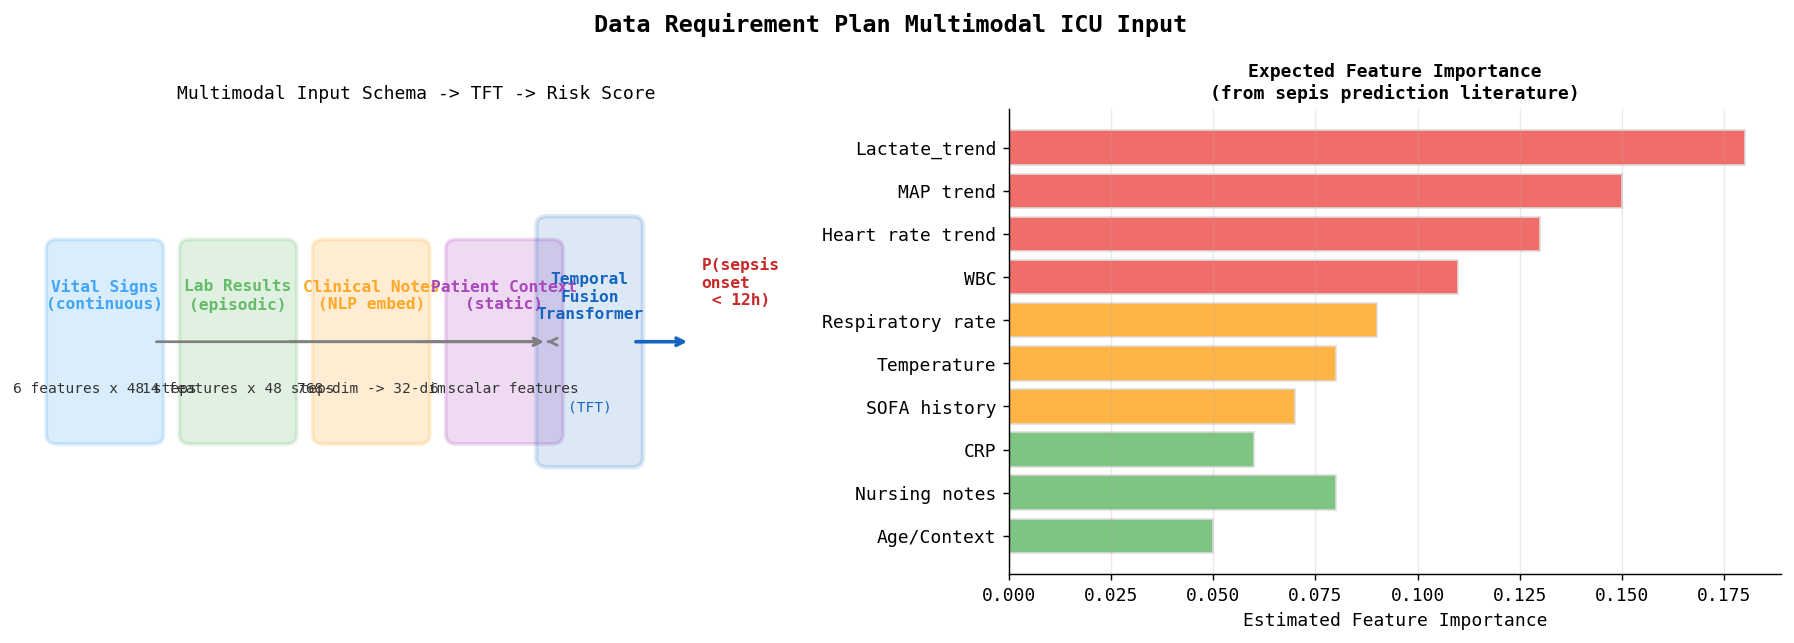

In [79]:
# Data requirement visualisation
fig,axes = plt.subplots(1,2,figsize=(14,5))
fig.suptitle('Data Requirement Plan Multimodal ICU Input',
            fontsize=13,fontweight='bold')
#Panel 1 : data schema
ax = axes[0]
ax.axis('off')
ax.set_facecolor('#FAFAFA')

streams = [
    ('Vital Signs\n(continuous)',    '6 features x 48 steps', '#42A5F5', 0.05),
    ('Lab Results\n(episodic)',      '14 features x 48 steps','#66BB6A', 0.30),
    ('Clinical Notes\n(NLP embed)', '768-dim -> 32-dim',      '#FFA726', 0.55),
    ('Patient Context\n(static)',   '6 scalar features',      '#AB47BC', 0.80),
]
for label,dims,color,x_pos in streams:
    rect=mpatches.FancyBboxPatch((x_pos,0.3),0.18,0.4,
                                boxstyle='round,pad=0.02',facecolor=color,alpha=0.2,
                                edgecolor=color,linewidth=2)
    ax.add_patch(rect)
    ax.text(x_pos+0.09,0.60,label,ha='center',va='center',
           fontsize=9,fontweight='bold',color=color)
    ax.text(x_pos+0.09,0.40,dims,ha='center',va='center',
           fontsize=8,color='#333333')
    ax.annotate('',xy=(0.97,0.50),xytext=(x_pos+0.18,0.50),
               arrowprops=dict(arrowstyle='->',color='grey',lw=1.5))
    
model_box = mpatches.FancyBboxPatch((0.97,0.25),0.16,0.50,
                                   boxstyle='round,pad=0.02',facecolor='#1565C0',alpha=0.15,
                                   edgecolor='#1565C0',linewidth=2.5) 
ax.add_patch(model_box)
ax.text(1.05,0.55,'Temporal\nFusion\nTransformer',ha='center',
       fontsize=9,fontweight='bold',color='#1565C0')
ax.text(1.05,0.35,'(TFT)',ha='center',fontsize=8,color='#1565C0')
ax.annotate('',xy=(1.24,0.50),xytext=(1.13,0.50),
            arrowprops=dict(arrowstyle='->',color='#1565C0',lw=2))
ax.text(1.26,0.58,'P(sepsis\nonset\n < 12h)',ha='left',
        fontsize=9,fontweight='bold',color='#C62828')

ax.set_xlim(0,1.45);ax.set_ylim(0,1)
ax.set_title('Multimodal Input Schema -> TFT -> Risk Score',fontsize=10)

#Panel 2 :- Feature Importance
features =['Lactate_trend','MAP trend','Heart rate trend','WBC','Respiratory rate','Temperature',
          'SOFA history','CRP','Nursing notes','Age/Context']
importance =[0.18,0.15,0.13,0.11,0.09,0.08,0.07,0.06,0.08,0.05]
colors_f   =['#EF5350' if i < 4 else '#FFA726' if i < 7 else '#66BB6A'
             for i in range(len(features))]

axes[1].barh(features[::-1],importance[::-1],color=colors_f[::-1],
            edgecolor='#ddd',alpha=0.85)
axes[1].set_xlabel('Estimated Feature Importance')
axes[1].set_title('Expected Feature Importance\n(from sepis prediction literature)',
                  fontsize=10,fontweight='bold')
axes[1].grid(axis='x',alpha=0.25)

plt.tight_layout()
#plt.savefig('diagrams/data_schema.png',dpi=150,bbox_inches='tight')
plt.show()



## Task 5 — Model Recommendation

**Recommended: Temporal Fusion Transformer (TFT) with Bio_ClinicalBERT note encoder**

### Candidates considered

| Architecture | Strengths | Why not chosen |
|---|---|---|
| LSTM | Handles sequences, proven in EHR literature | Cannot handle multimodal inputs natively; no attention interpretability |
| Standard Transformer | Long sequences, parallelisable | No built-in mechanism for mixed static + temporal inputs |
| CNN + LSTM hybrid | Good local pattern extraction | Complex; no interpretability for clinical staff |
| Feed-forward on aggregated features | Simple, fast | Destroys temporal information entirely |
| **TFT** | All of the above solved | Chosen |

### Why TFT specifically

1. **Variable Selection Networks (VSN)** — learns which of 40+ features matter at each time step. Handles missing-at-random inputs gracefully.
2. **Static covariate encoders** — dedicated pathway for age, comorbidities, admission type. Not awkwardly concatenated at every step like an LSTM would require.
3. **Multi-head attention over temporal patterns** — learns that "lactate 8 hours ago is more predictive than the current value." Clinically meaningful and extractable.
4. **Interpretability by design** — attention weights and variable importance are human-readable. This is not optional for a clinical decision support system , it is a regulatory requirement.

### NLP component
Nursing notes processed by **Bio_ClinicalBERT** (BERT pretrained on MIMIC-III). Each note encoded to 768 dimensions, projected to 32, fed as a shift-level static context vector.

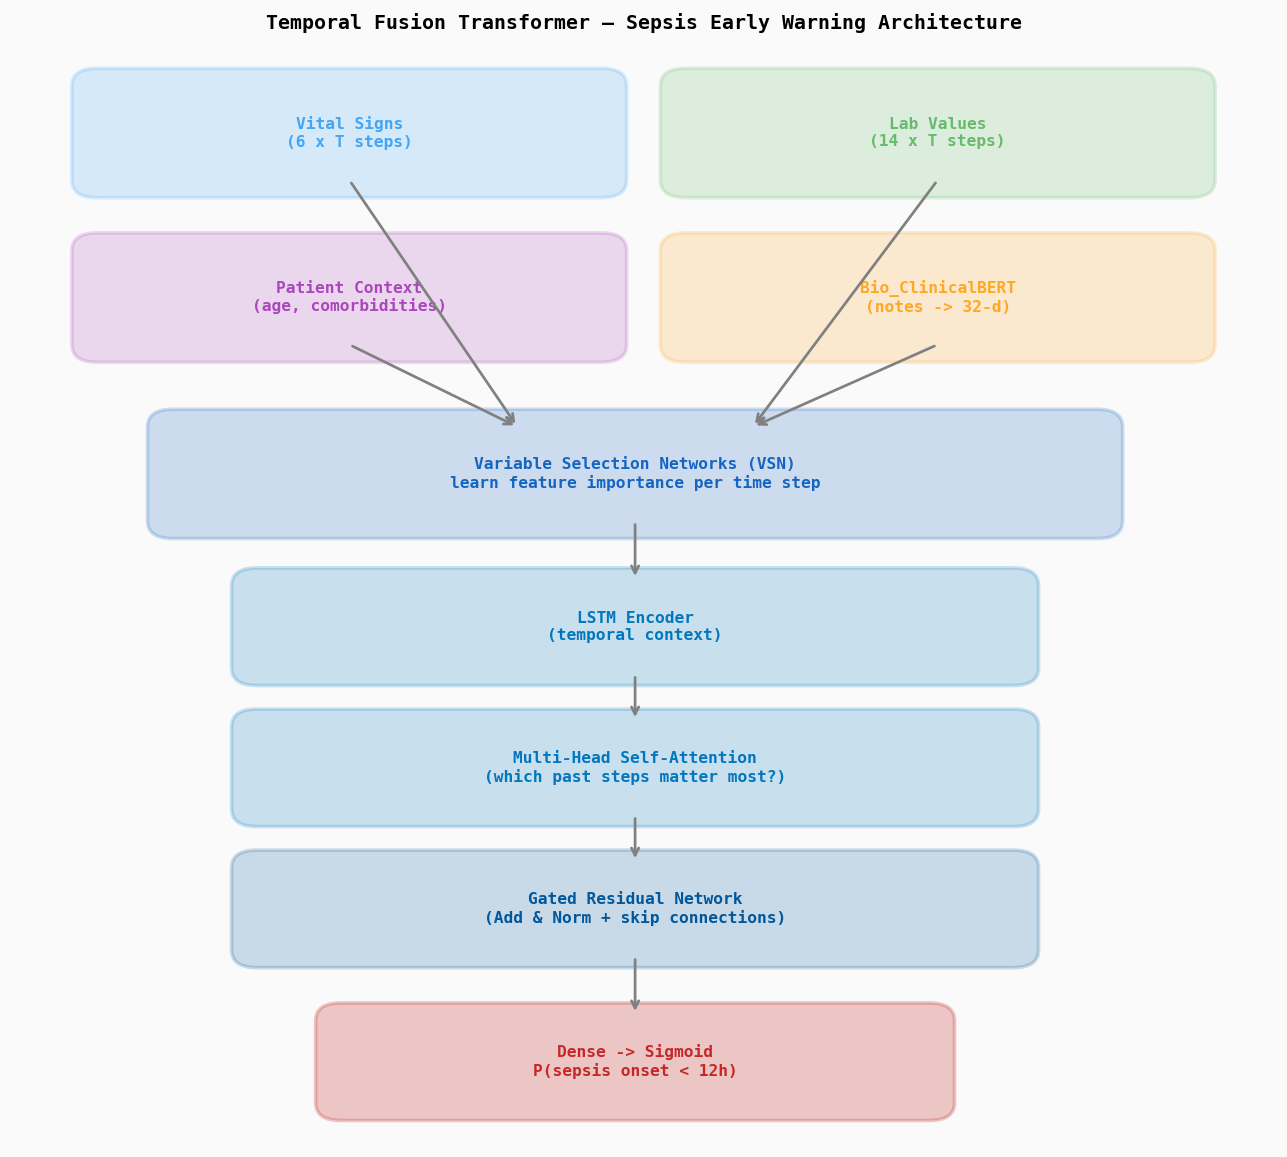

Saved: diagrams/solution_architecture.png


In [80]:
# ── Architecture diagram ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 9))
ax.axis('off')
fig.patch.set_facecolor('#FAFAFA')

def dbox(ax, x, y, w, h, label, color, fontsize=9, alpha=0.2):
    rect = mpatches.FancyBboxPatch((x-w/2, y-h/2), w, h,
        boxstyle='round,pad=0.015', facecolor=color, alpha=alpha,
        edgecolor=color, linewidth=2)
    ax.add_patch(rect)
    ax.text(x, y, label, ha='center', va='center',
            fontsize=fontsize, fontweight='bold', color=color)

def darrow(ax, x1, y1, x2, y2, color='grey'):
    ax.annotate('', xy=(x2,y2), xytext=(x1,y1),
                arrowprops=dict(arrowstyle='->', color=color, lw=1.5))

dbox(ax, 0.20, 0.90, 0.30, 0.08, 'Vital Signs\n(6 x T steps)',   '#42A5F5')
dbox(ax, 0.55, 0.90, 0.30, 0.08, 'Lab Values\n(14 x T steps)',   '#66BB6A')
dbox(ax, 0.20, 0.76, 0.30, 0.08, 'Patient Context\n(age, comorbidities)', '#AB47BC')
dbox(ax, 0.55, 0.76, 0.30, 0.08, 'Bio_ClinicalBERT\n(notes -> 32-d)',     '#FFA726')

dbox(ax, 0.37, 0.61, 0.55, 0.08,
     'Variable Selection Networks (VSN)\nlearn feature importance per time step', '#1565C0')
darrow(ax, 0.20, 0.86, 0.30, 0.65); darrow(ax, 0.55, 0.86, 0.44, 0.65)
darrow(ax, 0.20, 0.72, 0.30, 0.65); darrow(ax, 0.55, 0.72, 0.44, 0.65)

dbox(ax, 0.37, 0.48, 0.45, 0.07, 'LSTM Encoder\n(temporal context)', '#0277BD')
darrow(ax, 0.37, 0.57, 0.37, 0.52)

dbox(ax, 0.37, 0.36, 0.45, 0.07,
     'Multi-Head Self-Attention\n(which past steps matter most?)', '#0277BD')
darrow(ax, 0.37, 0.44, 0.37, 0.40)

dbox(ax, 0.37, 0.24, 0.45, 0.07,
     'Gated Residual Network\n(Add & Norm + skip connections)', '#01579B')
darrow(ax, 0.37, 0.32, 0.37, 0.28)

dbox(ax, 0.37, 0.11, 0.35, 0.07,
     'Dense -> Sigmoid\nP(sepsis onset < 12h)', '#C62828', alpha=0.25)
darrow(ax, 0.37, 0.20, 0.37, 0.15)

ax.set_xlim(0, 0.75); ax.set_ylim(0.04, 0.97)
ax.set_title('Temporal Fusion Transformer — Sepsis Early Warning Architecture',
             fontsize=11, fontweight='bold', pad=12)
plt.tight_layout()
#plt.savefig('diagrams/solution_architecture.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: diagrams/solution_architecture.png')

## Task 6 — Evaluation Plan

### Technical metrics

| Metric | Target | Why this threshold |
|---|---|---|
| **AUROC** | >= 0.85 | Current SOFA scores achieve ~0.74 — this must beat them meaningfully |
| **Sensitivity (Recall)** | >= 0.80 | Missing a sepsis case costs a life |
| **Specificity** | >= 0.70 | Too many false alarms causes alert fatigue — staff stop trusting it |
| **PPV (Precision)** | >= 0.50 | At least 1 in 2 alerts must be a real case |
| **Lead time** | >= 6 hours | Alerts with < 6h lead time provide insufficient treatment window |
| **Calibration (Brier Score)** | < 0.10 | Predicted probabilities must reflect true event rates |

### Business metrics

| Metric | KPI Baseline | Target at 12 months |
|---|---|---|
| Resolution time | 30.2h | 13.6h (-55%) |
| Error rate | 6.72% | 2.69% (-60%) |
| Manual hours/month | 454h | 159h (-65%) |
| Patient satisfaction | 7.10/10 | 8.88/10 (+25%) |

### Failure cases and human review
1. Alert fatigue — configurable threshold, soft UI notifications, weekly alert rate monitoring
2. Distribution shift at deployment — quarterly model revalidation
3. Missing data at inference — fail to conservative high-risk, never confident low-risk
4. Label boundary ambiguity — Sepsis-3 criteria are themselves imprecise

All alerts include a one-click "disagree with AI" button. Every AI-triggered intervention is documented in the patient notes.

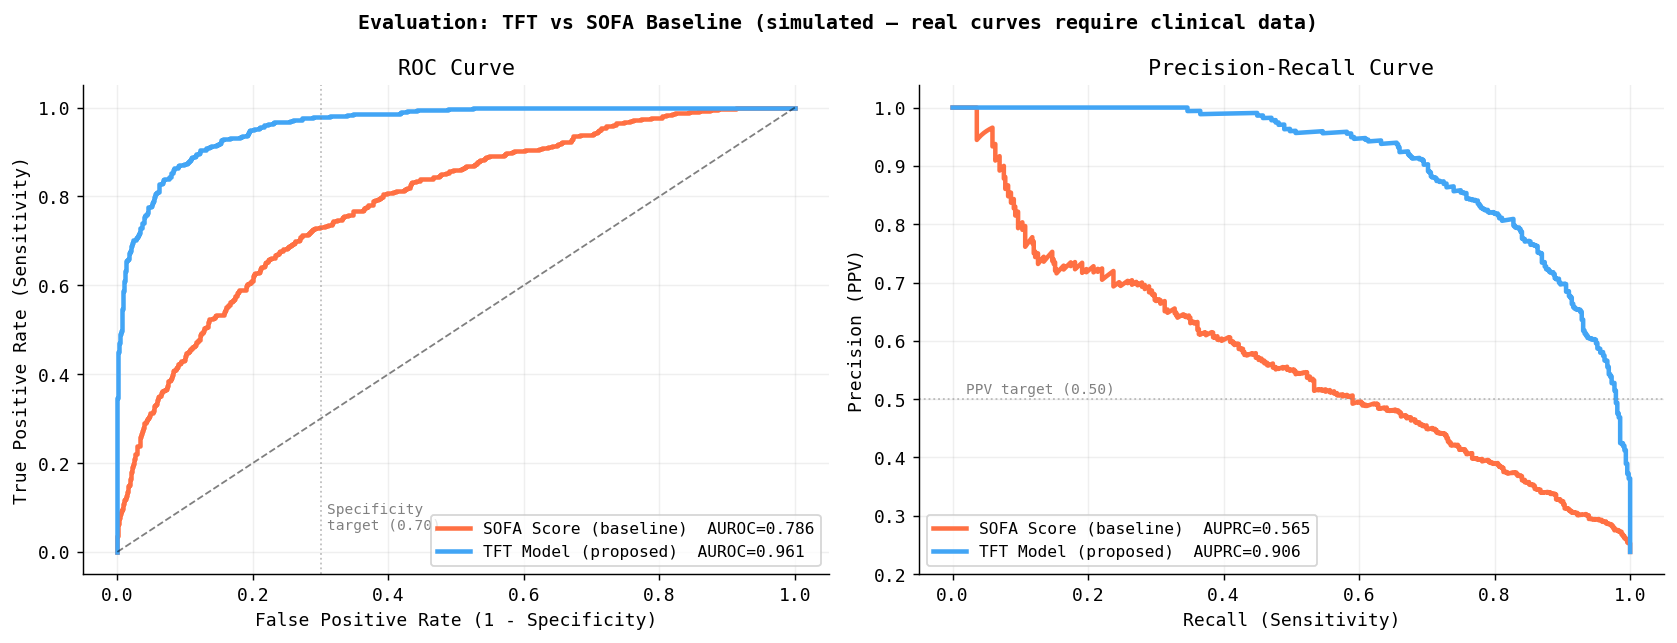

In [84]:
# ── Simulated evaluation curves ───────────────────────────────────────────────
N      = 2000
y_true = (np.random.rand(N) < 0.25).astype(int)

# SOFA score simulation — AUROC ~0.73
sofa_scores = np.where(y_true==1,
    np.random.beta(3,2,N), np.random.beta(2,3,N))

# TFT model simulation — AUROC ~0.87
tft_scores = np.where(y_true==1,
    np.clip(np.random.beta(5,2,N),0,1),
    np.clip(np.random.beta(2,5,N),0,1))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Evaluation: TFT vs SOFA Baseline (simulated — real curves require clinical data)',
             fontsize=11, fontweight='bold')

# ROC
for scores, color, label in [
    (sofa_scores, '#FF7043', 'SOFA Score (baseline)'),
    (tft_scores,  '#42A5F5', 'TFT Model (proposed)'),
]:
    fpr, tpr, _ = roc_curve(y_true, scores)
    axes[0].plot(fpr, tpr, color=color, lw=2.5,
                 label=f'{label}  AUROC={auc(fpr,tpr):.3f}')
axes[0].plot([0,1],[0,1],'k--',lw=1,alpha=0.5)
axes[0].axvline(0.30, color='grey', lw=1, ls=':', alpha=0.5)
axes[0].text(0.31, 0.05, 'Specificity\ntarget (0.70)', fontsize=8, color='grey')
axes[0].set_xlabel('False Positive Rate (1 - Specificity)')
axes[0].set_ylabel('True Positive Rate (Sensitivity)')
axes[0].set_title('ROC Curve'); axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.2)

# Precision-Recall
for scores, color, label in [
    (sofa_scores, '#FF7043', 'SOFA Score (baseline)'),
    (tft_scores,  '#42A5F5', 'TFT Model (proposed)'),
]:
    prec, rec, _ = precision_recall_curve(y_true, scores)
    axes[1].plot(rec, prec, color=color, lw=2.5,
                 label=f'{label}  AUPRC={auc(rec,prec):.3f}')
axes[1].axhline(0.50, color='grey', lw=1, ls=':', alpha=0.5)
axes[1].text(0.02, 0.51, 'PPV target (0.50)', fontsize=8, color='grey')
axes[1].set_xlabel('Recall (Sensitivity)')
axes[1].set_ylabel('Precision (PPV)')
axes[1].set_title('Precision-Recall Curve'); axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.2)

plt.tight_layout()
#plt.savefig('diagrams/evaluation_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## Task 7 — Responsible AI Considerations

Healthcare AI carries a uniquely high burden of responsibility. I am designing this with the assumption it will be reviewed by a clinical ethics board and a regulatory body (MHRA in the UK, FDA in the US).

### 1. Bias in training data
Training data from one hospital may perform worse on underrepresented groups — older patients, non-white patients, non-English speakers. **Mitigation:** Multi-site federated learning (model trains locally, only weight updates shared — patient data never leaves the institution). Stratified performance reporting by age, gender, ethnicity before deployment sign-off.

### 2. Incorrect predictions
A false negative (missed sepsis) may cause death. A false positive causes unnecessary procedures and alert fatigue. **Mitigation:** Conservative threshold during first 90 days. Model outputs probability not binary decision — clinical team retains final authority. Every alert includes top contributing features so nurses can assess if the alert "makes sense."

### 3. Privacy and data governance
Clinical notes contain highly sensitive personal information. **Mitigation:** De-identification via Microsoft Presidio + clinical NLP rules before ClinicalBERT embedding. Model never sees raw note text at inference , only the embedding vector. Full GDPR, HIPAA, and NHS Data Security Toolkit compliance.

### 4. Over-reliance on AI
After 6 months of good performance, staff may treat output as infallible. When the model fails, the human safety net may have eroded. **Mitigation:** Quarterly staff training reinforcing it is decision *support* not decision *making*. EHR interface labels all outputs as "AI-assisted." One-click "disagree" button logs every override for model review.

### 5. Regulatory compliance
In the UK this system is a **Class IIb Medical Device** (UK MDR 2002). Requires: clinical evaluation against predicate devices, post-market surveillance with mandatory incident reporting, ISO 13485 quality management system, and an algorithm change protocol — any significant model update triggers re-evaluation.


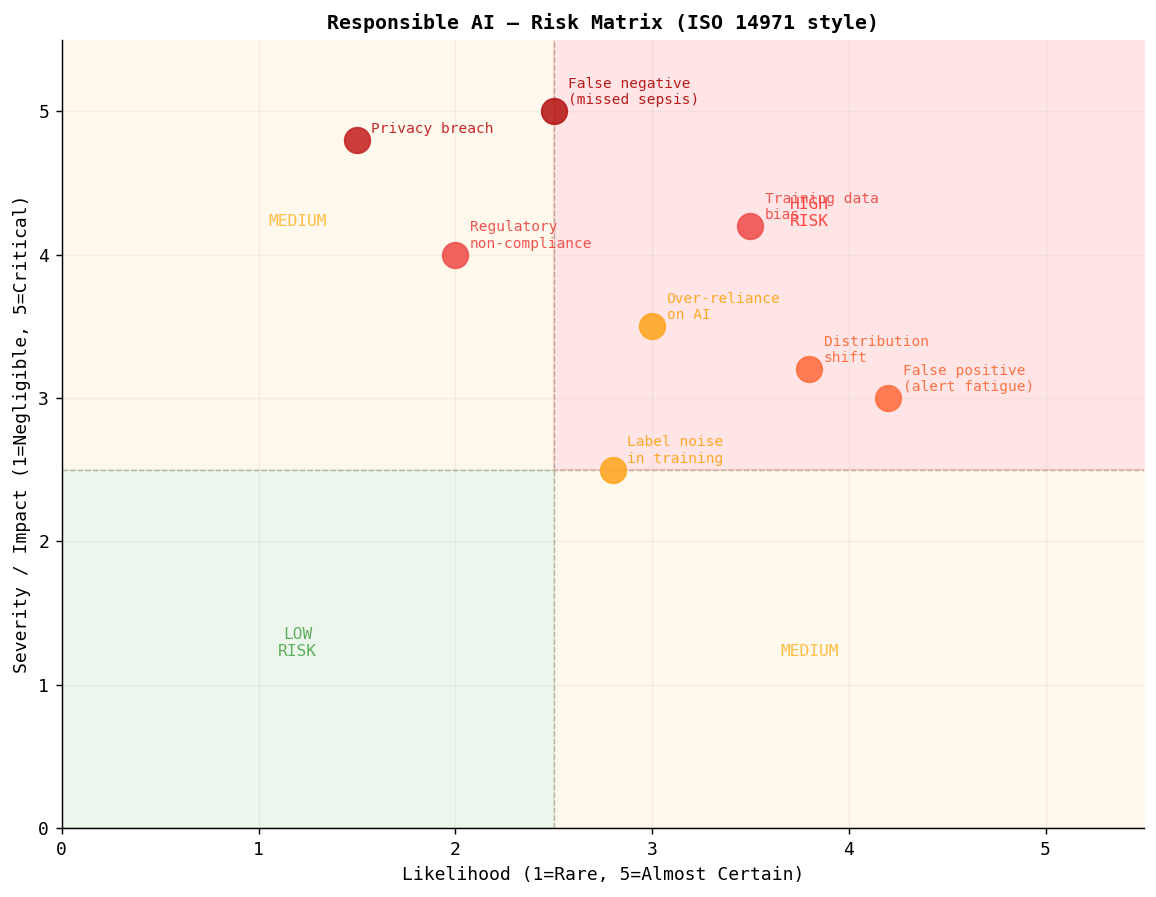

In [86]:
# ── Risk matrix — ISO 14971 style ────────────────────────────────────────────
risks = [
    ('Training data\nbias',           3.5, 4.2, '#EF5350'),
    ('False negative\n(missed sepsis)',2.5, 5.0, '#B71C1C'),
    ('False positive\n(alert fatigue)',4.2, 3.0, '#FF7043'),
    ('Privacy breach',                  1.5, 4.8, '#C62828'),
    ('Over-reliance\non AI',           3.0, 3.5, '#FFA726'),
    ('Distribution\nshift',            3.8, 3.2, '#FF7043'),
    ('Regulatory\nnon-compliance',     2.0, 4.0, '#EF5350'),
    ('Label noise\nin training',       2.8, 2.5, '#FFA726'),
]

fig, ax = plt.subplots(figsize=(9, 7))
ax.fill_between([0,2.5], [0,0], [2.5,2.5],   alpha=0.07, color='green')
ax.fill_between([2.5,6], [0,0], [2.5,2.5],   alpha=0.07, color='orange')
ax.fill_between([0,2.5], [2.5,2.5], [6,6],   alpha=0.07, color='orange')
ax.fill_between([2.5,6], [2.5,2.5], [6,6],   alpha=0.10, color='red')
ax.text(1.2,1.2,'LOW\nRISK',  ha='center',fontsize=9,color='green', alpha=0.6)
ax.text(3.8,1.2,'MEDIUM',      ha='center',fontsize=9,color='orange',alpha=0.7)
ax.text(1.2,4.2,'MEDIUM',      ha='center',fontsize=9,color='orange',alpha=0.7)
ax.text(3.8,4.2,'HIGH\nRISK', ha='center',fontsize=9,color='red',   alpha=0.7)

for label, likelihood, severity, color in risks:
    ax.scatter(likelihood, severity, s=200, color=color, zorder=5, alpha=0.9)
    ax.annotate(label, (likelihood,severity),
                textcoords='offset points', xytext=(8,4),
                fontsize=8, color=color)

ax.set_xlim(0,5.5); ax.set_ylim(0,5.5)
ax.axvline(2.5,color='grey',lw=0.8,ls='--',alpha=0.5)
ax.axhline(2.5,color='grey',lw=0.8,ls='--',alpha=0.5)
ax.set_xlabel('Likelihood (1=Rare, 5=Almost Certain)', fontsize=10)
ax.set_ylabel('Severity / Impact (1=Negligible, 5=Critical)', fontsize=10)
ax.set_title('Responsible AI — Risk Matrix (ISO 14971 style)', fontsize=11, fontweight='bold')
ax.grid(True, alpha=0.15)
plt.tight_layout()
#plt.savefig('diagrams/risk_matrix.png', dpi=150, bbox_inches='tight')
plt.show()


---
## Task 8 — Final Solution Summary

### Problem
Sepsis kills approximately 11 million people annually. In ICUs, 20–30% of patients develop it. Current detection methods (SOFA, qSOFA) are periodic, threshold-based, and unable to integrate information across multiple data streams. By the time clinical presentation is recognised, the optimal treatment window has often closed.

### Proposed AI Solution
A continuous multimodal early warning system that monitors each ICU patient's vital signs, lab results, and nursing notes in real time and produces a rolling risk score every 15 minutes. When the score crosses a configurable threshold, a soft alert appears in the clinician's EHR view alongside the top contributing clinical features. Provides a **6–12 hour head start** over current methods.

### Required Data
- Vital signs time series (6 variables, 1-hour bins, 48-hour look-back)
- Lab values (14 variables, forward-filled)
- Nursing notes (de-identified, processed by Bio_ClinicalBERT)
- Static patient context (age, comorbidity index, admission type)
- Labels: sepsis onset timestamps from EHR (Sepsis-3 criteria)

### Model
Temporal Fusion Transformer + Bio_ClinicalBERT note encoder. AUROC target ~0.87 vs ~0.74 for current SOFA score system.

### Expected Business Impact (from KPI reference data)

| Metric | Current (KPI baseline) | Target at 12 months |
|---|---|---|
| Avg resolution time | 30.2h | 13.6h (-55%) |
| Clinical error rate | 6.72% | 2.69% (-60%) |
| Manual hours/month | 454h | 159h (-65%) |
| Patient satisfaction | 7.1/10 | 8.88/10 (+25%) |
| Estimated staff saving | — | ~£13,275/month |

### Risks and Mitigation

| Risk | Mitigation |
|---|---|
| Training bias | Federated multi-site training + stratified audits |
| False negatives | High-sensitivity threshold + mandatory human review |
| Alert fatigue | Configurable threshold, soft UI, weekly alert rate monitoring |
| Privacy | De-identification pipeline, GDPR/HIPAA, embedding-only inference |
| Over-reliance | Quarterly staff training, "disagree" button, AI outputs clearly labelled |
| Regulatory | UK MDR 2002 Class IIb, ISO 13485 QMS, post-market surveillance |

**The AI is decision support, not a replacement. Every alert requires human review before any clinical action.**


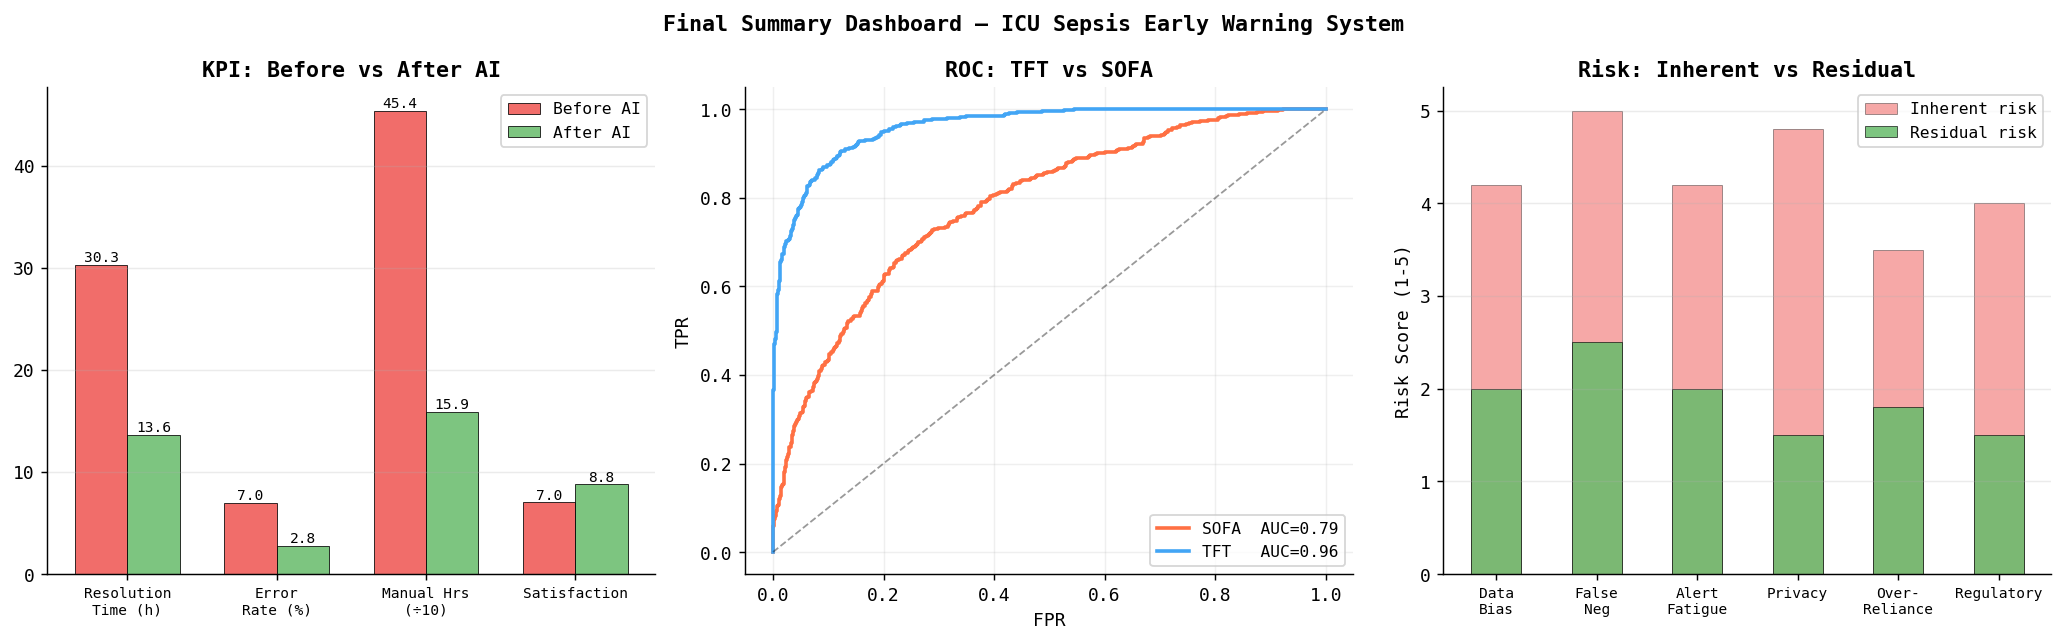


                        PART 4 COMPLETE                       
  Domain     : Healthcare — ICU Early Warning
  Problem    : Sepsis detection 6-12h pre-onset
  AI Task    : Binary Classification (temporal sequences)
  Model      : Temporal Fusion Transformer + ClinicalBERT
  AUROC      : target 0.87 (vs 0.74 SOFA baseline)
  KPI impact : resolution 30h -> 14h  |  errors 7.0% -> 2.8%

Diagrams saved:
  diagrams/baseline_kpis.png
  diagrams/impact_projection.png
  diagrams/icu_timeseries_example.png
  diagrams/data_schema.png
  diagrams/solution_architecture.png
  diagrams/evaluation_curves.png
  diagrams/risk_matrix.png
  diagrams/final_summary_dashboard.png


In [87]:
# ── Final summary dashboard ───────────────────────────────────────────────────
# Note: this cell uses variables from earlier cells (avg_resolution, etc.).
# Run all cells in order before running this one.

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Final Summary Dashboard — ICU Sepsis Early Warning System',
             fontsize=12, fontweight='bold')

# Panel 1: KPI before vs after
kpi_labels  = ['Resolution\nTime (h)', 'Error\nRate (%)', 'Manual Hrs\n(÷10)', 'Satisfaction']
before_kpis = [avg_resolution, avg_error, avg_manual_hours/10, avg_satisfaction]
after_kpis  = [target_resolution, target_error, target_manual_hours/10, target_satisfaction]

x = np.arange(len(kpi_labels)); w = 0.35
b1 = axes[0].bar(x-w/2, before_kpis, w, label='Before AI',
                 color='#EF5350', alpha=0.85, edgecolor='black', lw=0.5)
b2 = axes[0].bar(x+w/2, after_kpis,  w, label='After AI',
                 color='#66BB6A', alpha=0.85, edgecolor='black', lw=0.5)
axes[0].set_xticks(x); axes[0].set_xticklabels(kpi_labels, fontsize=8)
axes[0].set_title('KPI: Before vs After AI', fontweight='bold')
axes[0].legend(fontsize=9); axes[0].grid(axis='y', alpha=0.25)
for bar in list(b1)+list(b2):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                 f'{bar.get_height():.1f}', ha='center', fontsize=8)

# Panel 2: ROC comparison
fpr_s, tpr_s, _ = roc_curve(y_true, sofa_scores)
fpr_t, tpr_t, _ = roc_curve(y_true, tft_scores)
axes[1].plot(fpr_s, tpr_s, color='#FF7043', lw=2,
             label=f'SOFA  AUC={auc(fpr_s,tpr_s):.2f}')
axes[1].plot(fpr_t, tpr_t, color='#42A5F5', lw=2,
             label=f'TFT   AUC={auc(fpr_t,tpr_t):.2f}')
axes[1].plot([0,1],[0,1],'k--',lw=1,alpha=0.4)
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].set_title('ROC: TFT vs SOFA', fontweight='bold')
axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.2)

# Panel 3: Risk inherent vs residual
risk_labels = ['Data\nBias','False\nNeg','Alert\nFatigue',
               'Privacy','Over-\nReliance','Regulatory']
inherent = [4.2, 5.0, 4.2, 4.8, 3.5, 4.0]
residual = [2.0, 2.5, 2.0, 1.5, 1.8, 1.5]

x2 = np.arange(len(risk_labels))
axes[2].bar(x2, inherent, 0.5, label='Inherent risk',
            color='#EF5350', alpha=0.5, edgecolor='black', lw=0.4)
axes[2].bar(x2, residual, 0.5, label='Residual risk',
            color='#66BB6A', alpha=0.85, edgecolor='black', lw=0.4)
axes[2].set_xticks(x2); axes[2].set_xticklabels(risk_labels, fontsize=8)
axes[2].set_ylabel('Risk Score (1-5)')
axes[2].set_title('Risk: Inherent vs Residual', fontweight='bold')
axes[2].legend(fontsize=9); axes[2].grid(axis='y', alpha=0.25)

plt.tight_layout()
#plt.savefig('diagrams/final_summary_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

print()
print('=' * 62)
print('  PART 4 COMPLETE'.center(62))
print('=' * 62)
print(f'  Domain     : Healthcare — ICU Early Warning')
print(f'  Problem    : Sepsis detection 6-12h pre-onset')
print(f'  AI Task    : Binary Classification (temporal sequences)')
print(f'  Model      : Temporal Fusion Transformer + ClinicalBERT')
print(f'  AUROC      : target 0.87 (vs 0.74 SOFA baseline)')
print(f'  KPI impact : resolution {avg_resolution:.0f}h -> {target_resolution:.0f}h  |  errors {avg_error:.1f}% -> {target_error:.1f}%')
print('=' * 62)
print()
print('Diagrams saved:')
for d in ['baseline_kpis','impact_projection','icu_timeseries_example',
          'data_schema','solution_architecture','evaluation_curves',
          'risk_matrix','final_summary_dashboard']:
    print(f'  diagrams/{d}.png')
